# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran

In [2]:
from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor

# Simulating data

## Single df

### Creating

In [3]:
gdf_output = return_spatial_geo_df3(n_x = 40,  
    n_y = 20,    
    spacing = 100, 

    treated_scope_x_start = 10,
    treated_scope_x_end = 24,
    treated_scope_y_start = 7,
    treated_scope_y_end = 13,

    ATT_target = 1.5,

    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 25,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 11,

    rho = 0.15,

    spatial_confounder_scope_x_start = 12,
    spatial_confounder_scope_x_end = 32,
    spatial_confounder_scope_y_start = 2,
    spatial_confounder_scope_y_end = 18,

    lambda_cs = 0.2,
    max_treatment_spillover_distance = 400,
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)

#### Numerical checks

In [4]:
gdf_output[gdf_output['spill']!=0]

,unit_id,geometry,x,y,T,propensity,T_tot,C1,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y,Y_ns
127,1127,POINT (600 700),600,700,0,-0.933295,1,-0.833743,-1.038025,-1.020101,0.862036,0.005669,0.847055,0.006693,400.0,0.006693,-0.820644,-0.888230
128,1128,POINT (600 800),600,800,0,1.139500,1,0.003491,-0.413442,-0.117896,1.048818,0.005932,0.886361,0.006693,400.0,0.006693,0.670190,0.704978
129,1129,POINT (600 900),600,900,0,-0.747590,1,-1.339529,-0.140055,0.877868,-0.121376,0.002506,0.374361,0.006693,400.0,0.006693,-0.718099,-0.736845
130,1130,POINT (600 1000),600,1000,0,0.214551,1,-0.152702,0.069718,2.018831,-1.241388,0.007317,1.093324,0.006693,400.0,0.006693,-0.172546,-0.106163
131,1131,POINT (600 1100),600,1100,0,-1.186990,1,0.777042,-1.478278,0.100138,-1.611308,0.007400,1.105588,0.006693,400.0,0.006693,-1.147737,-1.135239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,1569,POINT (2800 900),2800,900,0,2.044651,1,0.159484,0.683526,0.190681,1.693622,0.007986,1.193178,0.006693,400.0,0.006693,1.388912,1.388912
570,1570,POINT (2800 1000),2800,1000,0,-2.108283,1,-0.937484,-0.553594,-1.582729,-0.097660,0.005174,0.773076,0.006693,400.0,0.006693,-1.263487,-1.263487
571,1571,POINT (2800 1100),2800,1100,0,0.192567,1,0.312503,1.206490,0.289408,-1.489678,0.008493,1.268993,0.006693,400.0,0.006693,-0.118743,-0.118743
572,1572,POINT (2800 1200),2800,1200,0,1.587772,1,1.654801,0.712730,-0.145565,0.007332,0.009146,1.366490,0.006693,400.0,0.006693,1.458770,1.458770


In [5]:
gdf_output['spill'].unique()

array([0.        , 0.00669285, 0.01774272, 0.0518728 , 0.07585818,
       0.11194084, 0.35659586, 0.5       , 0.8122148 , 0.92414182,
       1.        ])

In [6]:
gdf_output[(gdf_output['T_tot']!=0)
            #&(gdf_output2['T']!=0)
            ]['tau'].mean()

np.float64(0.7268404241440386)

In [7]:
gdf_output[(gdf_output['T_tot']!=0)
            &(gdf_output['T']!=0)
            ]['tau'].mean()

np.float64(1.4999999999999998)

In [8]:
gdf_output[gdf_output['T']==1]

,unit_id,geometry,x,y,T,propensity,T_tot,C1,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y,Y_ns
207,1207,POINT (1000 700),1000,700,1,0.737636,1,0.186640,1.060731,0.268984,0.779964,1.588383,1.588383,1.0,0.0,1.0,3.273119,3.165331
208,1208,POINT (1000 800),1000,800,1,1.520198,1,0.921466,-0.272364,-0.739786,0.997402,1.702612,1.702612,1.0,0.0,1.0,3.025741,2.818119
209,1209,POINT (1000 900),1000,900,1,-2.076687,1,-1.426007,0.337140,-1.405730,-0.350462,0.739261,0.739261,1.0,0.0,1.0,-0.154922,-0.588706
210,1210,POINT (1000 1000),1000,1000,1,1.606978,1,0.626080,-1.282209,1.510728,0.636210,1.774286,1.774286,1.0,0.0,1.0,2.921372,2.855811
211,1211,POINT (1000 1100),1000,1100,1,-3.951448,1,-2.073880,-1.346069,-0.813569,-1.468025,0.361022,0.361022,1.0,0.0,1.0,-2.690265,-2.693984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,1489,POINT (2400 900),2400,900,1,-0.395411,1,-0.015781,-0.782297,-0.355875,-0.081787,1.052091,1.052091,1.0,0.0,1.0,0.527082,0.482108
490,1490,POINT (2400 1000),2400,1000,1,-3.131737,1,-0.713480,-2.420328,-1.011393,-0.425064,0.914520,0.914520,1.0,0.0,1.0,-1.791754,-2.011255
491,1491,POINT (2400 1100),2400,1100,1,-0.690957,1,-0.353700,1.095787,-0.137622,-0.934055,1.639748,1.639748,1.0,0.0,1.0,1.629211,1.568538
492,1492,POINT (2400 1200),2400,1200,1,1.384523,1,1.855994,-1.248035,1.168447,0.235101,1.656459,1.656459,1.0,0.0,1.0,3.286561,3.286561


In [9]:
gdf_output.isna().any().any()

np.False_

In [10]:
coords = np.array(list(zip(gdf_output["x"], gdf_output["y"])))

W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
W.transform = "R" 
moran_I_y= Moran(gdf_output['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

['Moran I: 0.1797', 'p-value simulated: 0.0010']

#### Visual checks

In [11]:
gdf_output3 = gdf_output.copy()
gdf_output3['spill2'] = gdf_output3['spill'] + 0.5

<Axes: >

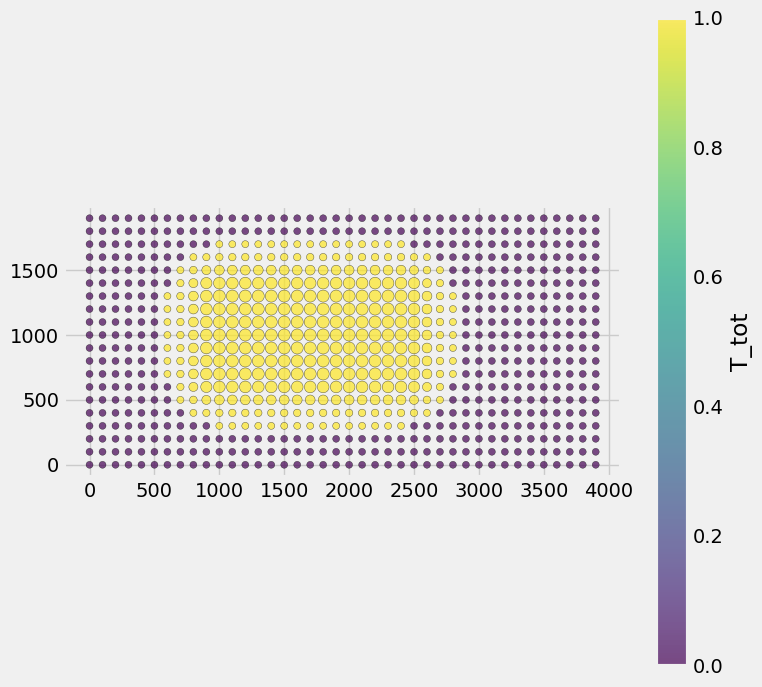

In [12]:
plot_gdf_points(gdf_output3, size_col='spill2',
    color_col='T_tot')

<Axes: >

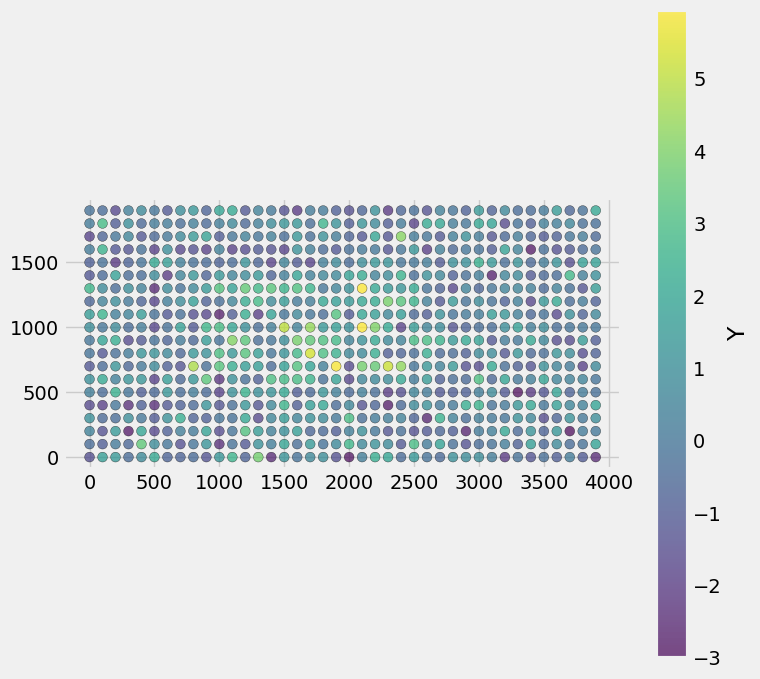

In [13]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='Y')

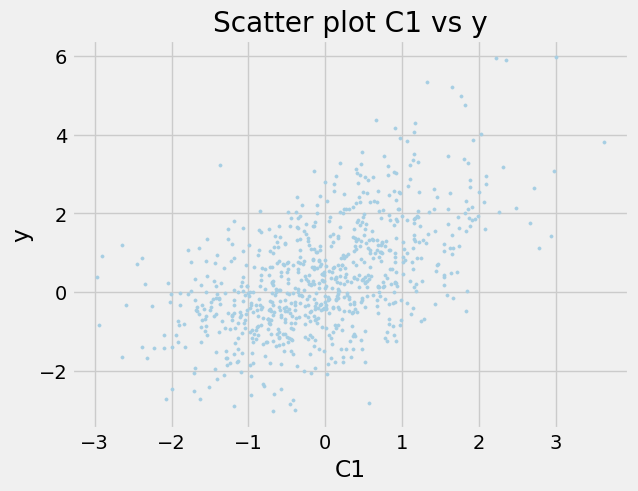

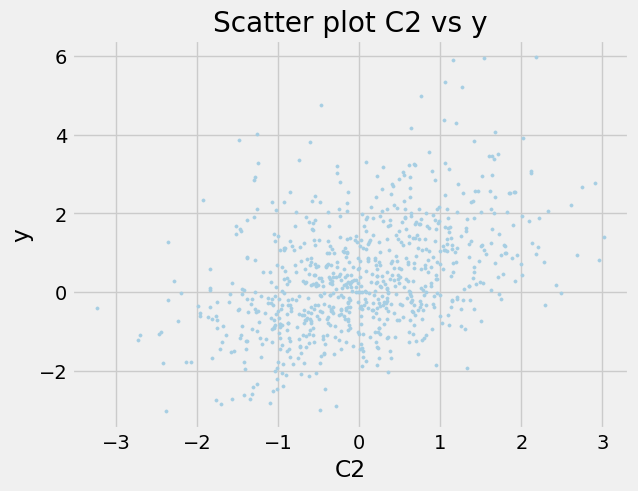

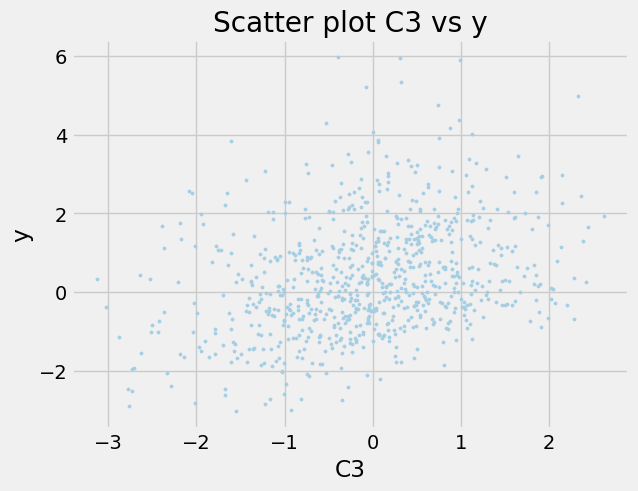

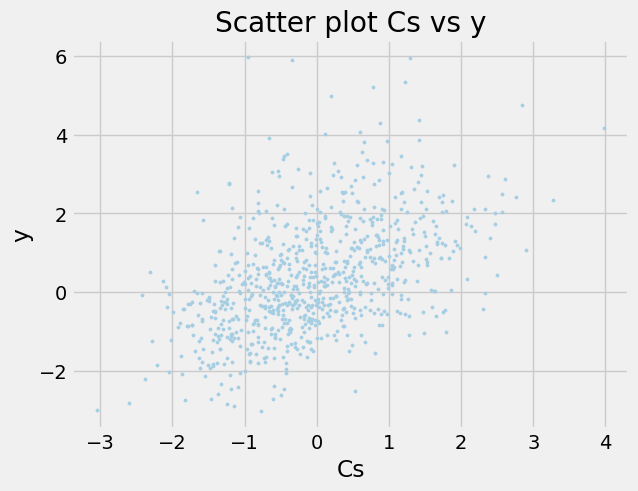

In [14]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y", s=5)
    plt.xlabel(i)
    plt.ylabel("y")
    plt.title(f"Scatter plot {i} vs y")
    plt.show()

#### Modelling checks

##### Data

In [15]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y"].values.reshape(-1,1)
T = gdf_output["T"].values
T_tot = gdf_output["T_tot"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
Xdf2 = gdf_output[["C1","C2",'T_tot',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
y_l = gdf_output["Y_ns"]
Y = gdf_output['Y'].values

X_logit = sm.add_constant(X)

##### Logit for T

In [16]:
logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.387174
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  800
Model:                          Logit   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Mon, 11 May 2026   Pseudo R-squ.:                0.004070
Time:                        21:52:33   Log-Likelihood:                -309.74
converged:                       True   LL-Null:                       -311.00
Covariance Type:            nonrobust   LLR p-value:                    0.2820
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8923      0.105    -17.989      0.000      -2.098      -1.686
x1             0.1615      0.

##### Cross sectional linear difference in differences 

In [17]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.578
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     363.6
Date:                Mon, 11 May 2026   Prob (F-statistic):          1.15e-148
Time:                        21:52:33   Log-Likelihood:                -1055.7
No. Observations:                 800   AIC:                             2119.
Df Residuals:                     796   BIC:                             2138.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1914      0.035      5.547      0.0

In [18]:
model = sm.OLS(y_l, X_l2)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     295.7
Date:                Mon, 11 May 2026   Prob (F-statistic):          6.07e-129
Time:                        21:52:33   Log-Likelihood:                -1101.4
No. Observations:                 800   AIC:                             2211.
Df Residuals:                     796   BIC:                             2229.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1127      0.044      2.586      0.0

##### Cross sectional difference in differences with spatial lag of Y

In [19]:
model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           Y                Number of Observations:         800
Mean dependent var  :      0.3821                Number of Variables   :           8
S.D. dependent var  :      1.4204                Degrees of Freedom    :         792
Pseudo R-squared    :      0.6001
Spatial Pseudo R-squared:  0.5931
Log likelihood      :  -1051.3133
Sigma-square ML     :      0.8059                Akaike info criterion :    2118.627
S.E of regression   :      0.8977                Schwarz criterion     :    2156.103

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----

##### Basic causal forest

###### For T

In [20]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T']==1]

,unit_id,geometry,T,tau,tau_cf
207,1207,POINT (1000 700),1,1.588383,2.141442
208,1208,POINT (1000 800),1,1.702612,1.899719
209,1209,POINT (1000 900),1,0.739261,0.929386
210,1210,POINT (1000 1000),1,1.774286,1.601692
211,1211,POINT (1000 1100),1,0.361022,-0.030831
...,...,...,...,...,...
489,1489,POINT (2400 900),1,1.052091,1.559071
490,1490,POINT (2400 1000),1,0.914520,-0.771005
491,1491,POINT (2400 1100),1,1.639748,1.611378
492,1492,POINT (2400 1200),1,1.656459,1.463229


In [21]:
ci_low_ate, ate, ci_high_ate

(np.float64(1.3163553429601582),
 np.float64(1.3578184486341562),
 np.float64(1.3992815543081543))

In [22]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

np.float64(1.3901375021582287)

###### For T tot

In [23]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T_tot)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T_tot, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T_tot', 'tau', 'tau_base']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T_tot']==1]

,unit_id,geometry,T_tot,tau,tau_base,tau_cf
127,1127,POINT (600 700),1,0.005669,0.847055,0.238524
128,1128,POINT (600 800),1,0.005932,0.886361,0.896980
129,1129,POINT (600 900),1,0.002506,0.374361,0.331007
130,1130,POINT (600 1000),1,0.007317,1.093324,0.619314
131,1131,POINT (600 1100),1,0.007400,1.105588,0.360814
...,...,...,...,...,...,...
569,1569,POINT (2800 900),1,0.007986,1.193178,0.624192
570,1570,POINT (2800 1000),1,0.005174,0.773076,0.376583
571,1571,POINT (2800 1100),1,0.008493,1.268993,0.946453
572,1572,POINT (2800 1200),1,0.009146,1.366490,1.307979


#### Multiple T DML

In [55]:
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures
est = LinearDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)


In [57]:
est.fit(Y, T_mult, X=X, 
        #W=W
        )

In [58]:
te_pred = est.const_marginal_effect(X)

In [59]:
te_pred

array([[ 1.860763  ,  0.90256524,  0.36887969,  0.11505855,  0.17864543],
       [ 1.0650805 ,  0.35731811,  0.10614891,  0.10361148,  0.0841577 ],
       [ 1.88800594,  0.86691002,  0.50294332,  0.09738654,  0.12271643],
       ...,
       [ 2.12093672,  0.96545414,  0.71555874,  0.10895095,  0.03946868],
       [ 1.63019796,  0.587918  ,  1.10392987, -0.22122673, -0.30335842],
       [ 1.92682477,  1.2727833 ,  0.28276638, -0.22553744,  0.26584919]],
      shape=(800, 5))

In [60]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
est2 = CausalForestDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2.tune(Y, T_mult, X=X, 
          #W=W
          )
est2.fit(Y, T_mult, X=X, 
         #W=W
         )

In [61]:
te_pred2 = est2.const_marginal_effect(X)

In [62]:
te_pred2

array([[ 1.62926042,  0.8029939 ,  0.52517485,  0.15228751,  0.01178702],
       [ 1.55474776,  0.77960642,  0.49800429,  0.15404443,  0.00766121],
       [ 1.64015571,  0.83228844,  0.5414186 ,  0.17007942,  0.02667964],
       ...,
       [ 1.72046501,  0.83698487,  0.56377948,  0.16506192,  0.01036242],
       [ 1.74433297,  0.76170478,  0.64316618,  0.12050116, -0.01785366],
       [ 1.70832025,  0.79530454,  0.45587392,  0.12357114,  0.0366786 ]],
      shape=(800, 5))

#### S learner with multiple treatments

In [24]:
X

array([[ 0.26509445,  0.00555455],
       [-0.53883439, -0.83830656],
       [ 0.44195196, -0.15664088],
       ...,
       [ 0.68747542,  0.20559026],
       [ 1.0674287 , -1.12734902],
       [ 0.18889183,  1.50409425]], shape=(800, 2))

In [25]:
gdf_output4 = gdf_output.copy()

In [27]:
gdf_output4['treated'] = 'control'

In [28]:
gdf_output4['treated'] = 'control'
gdf_output4.loc[(gdf_output4['spill'] == 1),'treated'] = 'inner_ring'
gdf_output4.loc[(gdf_output4['spill'] <= 0.924143)& (gdf_output4['spill'] >= 0.812214),'treated'] = 'outer_ring1'
gdf_output4.loc[(gdf_output4['spill'] <= 0.500001)& (gdf_output4['spill'] >= 0.356595),'treated'] = 'outer_ring2'
gdf_output4.loc[(gdf_output4['spill'] <= 0.111942)& (gdf_output4['spill'] >= 0.075857),'treated'] = 'outer_ring3'
gdf_output4.loc[(gdf_output4['spill'] <= 0.017744)& (gdf_output4['spill'] >= 0.006692),'treated'] = 'outer_ring4'


In [40]:
df_encoded = pd.get_dummies(gdf_output4, columns=['treated'], dtype=int)

In [44]:
T_mult = df_encoded[['treated_inner_ring',
    'treated_outer_ring1',
    'treated_outer_ring2',
    'treated_outer_ring3',
    'treated_outer_ring4']].to_numpy()

In [29]:
T_M= gdf_output4['treated'].values
T_M= T_M.astype(str)

In [30]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate, lb, ub = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df = pd.DataFrame(ite).rename(columns = {0:'inner_ring', 1:'outer_ring1', 
                                             2:'outer_ring2', 3:'outer_ring3',
                                             4:'outer_ring4'})
ITE_df['treated'] = T_M
ITE_df['ITE_real'] = gdf_output4['tau']
ITE_df['Y'] = Y

In [31]:
ate, lb, ub

(array([1.51162128, 0.44118779, 0.20215534, 0.01218957, 0.05881908]),
 array([ 1.40924098,  0.31844274,  0.05627723, -0.1076391 , -0.07330751]),
 array([1.61400159, 0.56393285, 0.34803344, 0.13201825, 0.19094567]))

In [32]:
ITE_df['treated'].unique()

array(['control', 'outer_ring4', 'outer_ring3', 'outer_ring2',
       'outer_ring1', 'inner_ring'], dtype=object)

In [ ]:
for i in ['outer_ring4', 'outer_ring3', 'outer_ring2', 'outer_ring1', 'inner_ring']:
    series_of_interest = ITE_df[ITE_df['treated']==i][i]
    att = series_of_interest.mean()
    se_att = (series_of_interest).std(ddof=1) / np.sqrt(len(series_of_interest))
    ci_low_att, ci_high_att = att - 1.96 * se_att, att + 1.96 * se_att
    print(i, 
          [ci_low_att, att, ci_high_att], 
          ITE_df[ITE_df['treated']==i]['ITE_real'].mean())

outer_ring4 [np.float64(-0.07165936837749545), np.float64(-0.00538509190890009), np.float64(0.060889184559695275)] 0.008738014342026776
outer_ring3 [np.float64(-0.08440597805421315), np.float64(-0.011823021711642859), np.float64(0.06075993463092744)] 0.07600716627326187
outer_ring2 [np.float64(0.03620292853444936), np.float64(0.08043839879025788), np.float64(0.1246738690460664)] 0.4428772043470615
outer_ring1 [np.float64(0.7599251867374754), np.float64(0.9153660643691627), np.float64(1.07080694200085)] 0.8655762790729669
inner_ring [np.float64(1.388204967332736), np.float64(1.5334973041293873), np.float64(1.6787896409260388)] 1.5000000000000002


In [ ]:
ITE_df

,inner_ring,outer_ring1,outer_ring2,outer_ring3,outer_ring4,treated,ITE_real,Y
0,1.529334,0.951125,0.012821,0.612198,0.308515,control,0.0,1.565688
1,0.248790,1.074960,0.116664,-0.200062,0.199073,control,0.0,-0.122890
2,1.000748,0.107895,0.015261,0.098745,-0.022816,control,0.0,1.640509
3,1.084204,0.493801,-0.131973,-0.117239,-0.273877,control,0.0,0.342295
4,1.438816,0.746394,0.042962,0.040821,0.003586,control,0.0,0.209687
...,...,...,...,...,...,...,...,...
795,0.786185,0.521010,-0.005905,-0.223544,-0.161874,control,0.0,-0.976647
796,0.916106,0.480884,0.020608,-0.002473,-0.222908,control,0.0,0.529602
797,1.028385,1.493971,0.188350,-0.011638,0.244113,control,0.0,1.422797
798,1.878361,0.084952,-0.002719,0.199975,0.040768,control,0.0,0.839998


In [ ]:
ITE_df[ITE_df['treated']=='inner_ring']['ITE_real'].mean()

np.float64(1.5000000000000002)

## Generating multiple df for simulations

### Data generation

In [ ]:
list_of_rhos = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
dict_of_output_gdf = {}
for i in list_of_rhos:
    single_gdf_output = return_spatial_geo_df(n_x = 40,  
        n_y = 20,    
        spacing = 100, 
        treated_scope_x_start = 10,
        treated_scope_x_end = 24,
        treated_scope_y_start = 7,
        treated_scope_y_end = 13,
        ATT_target = 1.5,
        y_spatial_autocorelation_scope_x_start = 3,
        y_spatial_autocorelation_scope_x_end = 25,
        y_spatial_autocorelation_scope_y_start = 4,
        y_spatial_autocorelation_scope_y_end = 11,
        rho = i,
        spatial_confounder_scope_x_start = 12,
        spatial_confounder_scope_x_end = 32,
        spatial_confounder_scope_y_start = 2,
        spatial_confounder_scope_y_end = 18,
        lambda_cs = 0.2,
        distance_ring_number = 2,
        distance_ring_ate_scalars=[0.4, 0.15],
        nonspatial_confounders_contribution_to_Y=1.0,
        spatial_confounder_contribution_to_Y=0.7,
        epsilon_distribution_mean = 0.025,
        epsilon_distribution_standard_error = 0.2)
    single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
    dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:]}'] = single_gdf_output2

In [ ]:
dict_of_output_gdf.keys()

In [ ]:
moran_I_y= Moran(dict_of_output_gdf['gdf_rho_0_55']['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

### Data saving

In [ ]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

In [ ]:
conn = sqlite3.connect(repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite')
cursor = conn.cursor()

In [ ]:
repo_path_r_string

In [ ]:
for k in dict_of_output_gdf.keys():
    dict_of_output_gdf[k].to_file(
        repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite',
        layer=k,
        driver="SQLite",
        #spatialite=True,
        #if_exists="replace"
    )